INFO:purepyindi2.transports:Connected to localhost:7624


Directory '/data/users/kianmilani/20260721' already exists.
0.30066145520144316


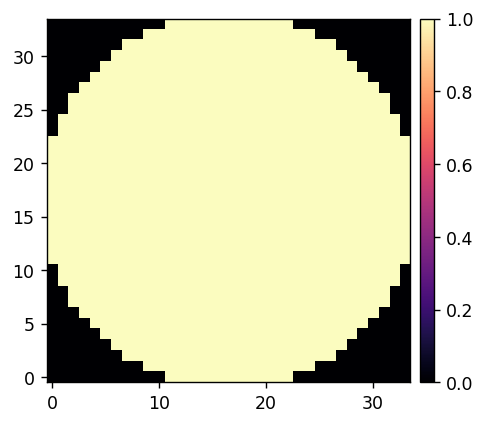

In [22]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils, scoob_utils

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'/data/users/kianmilani/{today}')
utils.make_dir(data_path)

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 1/3.326
print(camsci_pxscl_lamDc)

dm_mask = dm.create_mask(Nact=34)
utils.imshow([dm_mask])

In [2]:
reload(scoob_utils)

camsci_channel = 'camsci'

xc, yc = (4320, 3760)
ncamsci = 256
# ncamsci = 512
# ncamsci = 1024
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

scoob_utils.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel, delay=0.5)
scoob_utils.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)
scoob_utils.set_cam_gain(120, client0, cam_name=camsci_channel)
scoob_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

Set camsci ROI.
Set the camsci exposure time to 5.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 2.0


In [55]:
scoob_utils.set_fiber_atten(0.0, client0)

Set the fiber attenuation to 0.0


In [48]:
scoob_utils.set_fiber_atten(40, client0)

Set the fiber attenuation to 40.0


In [4]:
scoob_utils.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)

Set the camsci exposure time to 5.00e-03s


In [5]:
scoob_utils.set_cam_gain(120, client0, cam_name=camsci_channel)

Set the camsci gain setting to 120.0


In [6]:
scoob_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

Set the camsci blacklevel to 2.0


In [5]:
10**(-30/10) / 10**(-0/10)

0.001

In [14]:
scoob_utils.move_psf(1, 0, client0)

In [18]:
scoob_utils.move_psf(0, 1, client0)

In [23]:
reload(scoob_utils)

scoob_utils.home_filter_stage(client0)

In [7]:

scoob_utils.set_filter_stage_velocity(client0, 60, )

In [57]:
reload(scoob_utils)
scoob_utils.set_filter_stage_preset(client0, 'f1', ) # open state

In [56]:
reload(scoob_utils)
scoob_utils.set_filter_stage_preset(client0, 'f2', ) # blocked state

In [34]:
scoob_utils.set_filter_stage_angle(client0, 75)

In [23]:
scoob_utils.home_block(client0)

# Define the functions to take the image and to set the DM to a given command. 

In [26]:

CAMSCI_STREAM = ImageStream('camsci')


In [27]:
def take_im_fun(CAMSCI_STREAM, NFRAMES=10):
    coro_im = xp.array(np.mean(CAMSCI_STREAM.grab_many(NFRAMES), axis=0))
    return coro_im

take_im_params = {
    'CAMSCI_STREAM':CAMSCI_STREAM,
    'NFRAMES':10,
}


# Do the normalization

In [52]:
scoob_utils.set_cam_exp_time(0.001, client0, cam_name=camsci_channel)

Set the camsci exposure time to 1.00e-03s


In [50]:
scoob_utils.set_cam_exp_time(30, client0, cam_name=camsci_channel)

Set the camsci exposure time to 3.00e+01s


In [24]:
scoob_utils.move_block_in(client0)

In [6]:
reload(scoob_utils)
scoob_utils.set_filter_stage_preset(client0, 'f2', ) # blocked state

Saved data to:  /data/users/kianmilani/20260721/camsci_dark_30.000000s_120gain_19.30C_elliptec_no_leds_atten40.fits


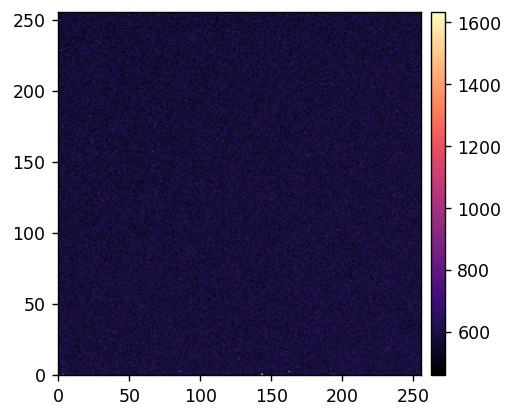

In [51]:
reload(rt_utils)
take_im_params.update({
    'NFRAMES':3,
})

exp_time = scoob_utils.get_cam_exp_time(client0, camsci_channel)
gain = scoob_utils.get_cam_gain(client0, camsci_channel)
cam_temp = client0['camsci.temp_ccd.current']

dark_im = take_im_fun(**take_im_params)
utils.save_fits(
    # data_path/f'camsci_dark_{exp_time:.6f}s_{gain:.0f}gain_{cam_temp:.2f}C_elliptec_pluggedin.fits', 
    # data_path/f'camsci_dark_{exp_time:.6f}s_{gain:.0f}gain_{cam_temp:.2f}C_elliptec_unplugged.fits', 
    # data_path/f'camsci_dark_{exp_time:.6f}s_{gain:.0f}gain_{cam_temp:.2f}C_elliptec_unplugged_2.fits',
    # data_path/f'camsci_dark_{exp_time:.6f}s_{gain:.0f}gain_{cam_temp:.2f}C_stagelinear_block.fits', 
    # data_path/f'camsci_dark_{exp_time:.6f}s_{gain:.0f}gain_{cam_temp:.2f}C_stagelinear_block_flipped.fits', 
    data_path/f'camsci_dark_{exp_time:.6f}s_{gain:.0f}gain_{cam_temp:.2f}C_elliptec_no_leds_atten40.fits', 
    dark_im,

)

utils.imshow([dark_im])

In [ ]:
scoob_utils.move_block_out(client0)

In [69]:
reload(scoob_utils)
scoob_utils.set_filter_stage_preset(client0, 'f1', ) # blocked state